In [4]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

In [48]:
# read results file
base_path = Path().cwd()

filename = "conv_gpt-35_rag_n-5_acc-0.774_08.22.2024-09:59:24"
filename += ".json"

file_under_investigation = base_path / "results" / filename
with file_under_investigation.open("r") as f:
    data = json.load(f)

In [49]:
# split responses and general stats
responses = pd.DataFrame(data["responses"])
del data["responses"]
stats = pd.DataFrame({k: [v]for k,v in data.items()})

In [50]:
# fetch incorrect instances
responses = responses.loc[responses["accuracy"] == False].copy()
responses.drop(columns=["ai_token_usage", "ai_response", "accuracy"], inplace=True)
responses.set_index("idx", inplace=True)

In [51]:
# get original sensors index
sensor_list = pd.read_excel("data/requirements.xlsx").columns[1:]

In [65]:
# get label per vector
func = lambda x: " & ".join(sensor_list[np.array(x[1:-1].split(",")) == "1"].tolist())
responses["true_label"] = responses["true_vector"].apply(func)
responses["pred_label"] = responses["pred_vector"].apply(func)

In [78]:
# save incorrect instances with labels
data_path = base_path / "data"

# get new version number
versions = [int(f.name.split("-")[-1].replace(".xlsx", "")) for f in data_path.glob("incorrect-instances_gpt-35-*.xlsx")]
new_version = max(versions) + 1

# save data
responses.to_excel(data_path / f"incorrect-instances_gpt-35-{new_version}.xlsx")

''

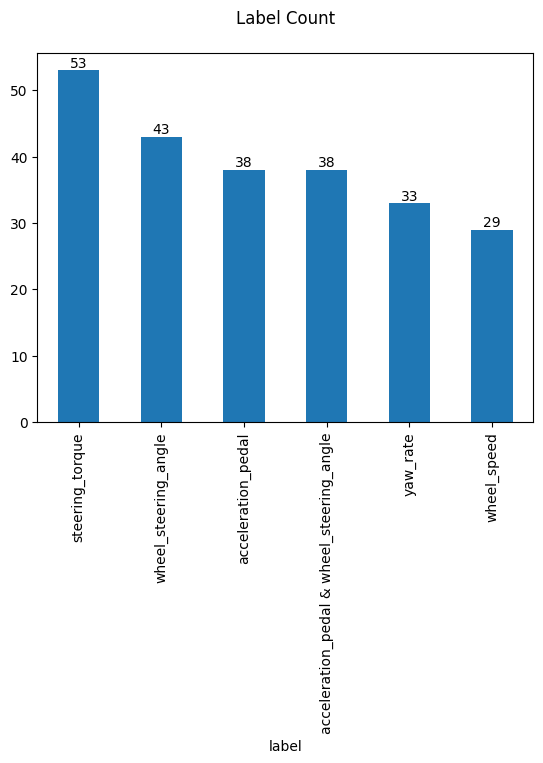

In [105]:
# visualize label count
df = pd.read_excel("data/requirements.xlsx")
df["label"] = [*map(lambda x: " & ".join(df.columns[1:][x==1]), df.iloc[:, 1:].to_numpy())]

ax = df["label"].value_counts().plot.bar(title="Label Count\n")
ax.bar_label(ax.containers[0])
""

''

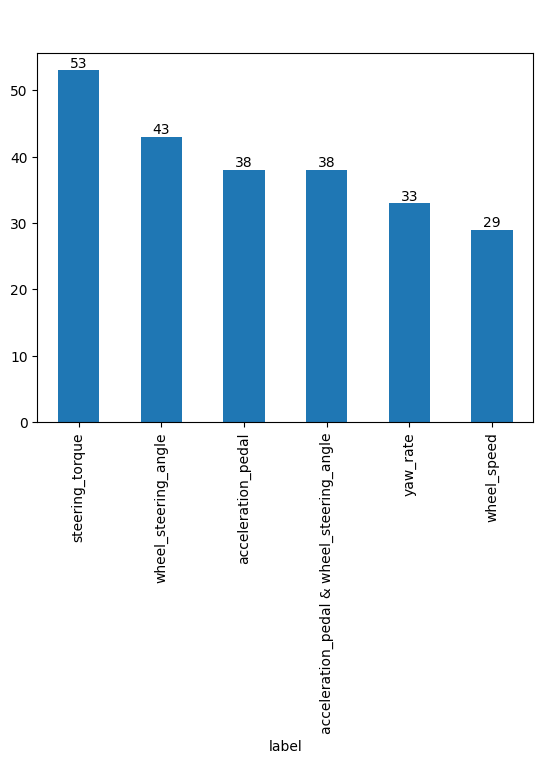